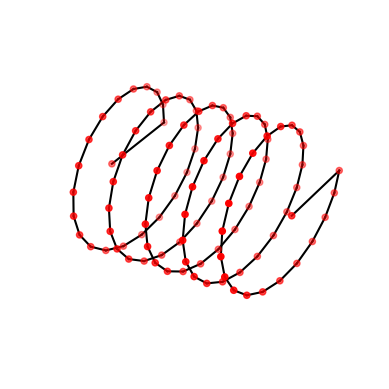

In [1]:
import numpy as np
import dismech

geom = dismech.GeomParams(rod_r0=5e-3,
                          shell_h=0)

material = dismech.Material(density=920,
                            youngs_rod=1e9,
                            youngs_shell=0,
                            poisson_rod=0.5,
                            poisson_shell=0)

static_2d_sim = dismech.SimParams(static_sim=False,
                                  two_d_sim=False,
                                  use_mid_edge=False,
                                  use_line_search=False,
                                  show_floor=False,
                                  log_data=True,
                                  log_step=1,
                                  dt=1e-2,
                                  max_iter=25,
                                  total_time=1,
                                  plot_step=1,
                                  tol=1e-4,
                                  ftol=1e-4,
                                  dtol=1e-2)

env = dismech.Environment()
env.add_force('damping', eta=1)
geo = dismech.Geometry.from_txt('../tests/resources/slinky/slinky.txt')
# geo = dismech.Geometry.from_txt('../tests/resources/rod_cantilever/horizontal_rod_n11.txt')

robot = dismech.SoftRobot(geom, material, geo, static_2d_sim, env)

In [2]:
fixed_points = [0, 1] # fix the first two nodes
end_node_idxs = [robot.n_nodes - 2, robot.n_nodes - 1] # pull the last two nodes
robot = robot.fix_nodes(np.union1d(fixed_points, end_node_idxs))
total_displacement = 0.1
factors = []
def pull(robot, t):
    # slowly increase the displacement of the last node to the right
    factor = min(t/robot.sim_params.total_time, 1.0)
    """ Simple example of a moving boundary condition """
        # [x, y, z]
    u0 = 1
        # [x, y, z]
    robot = robot.move_nodes(end_node_idxs, [u0 * robot.sim_params.dt, 0, 0])
    factors.append(factor)
    
    return robot

stepper = dismech.ImplicitEulerTimeStepper(robot)
stepper.before_step = pull

In [3]:
robots, t_arr, f_norms, Fs = stepper.simulate()

qs = np.stack([robot.state.q for robot in robots])
vs = np.stack([robot.state.u for robot in robots])
t_arr = np.array(t_arr)
Fs_arr = np.array(Fs)
factors.append(1.0) # add the final factor at the end of the simulation

iter: 1, error: 39697.332
iter: 2, error: 7432.733
iter: 3, error: 4957.174
iter: 4, error: 2026.647
iter: 5, error: 122.932
iter: 6, error: 283.149
iter: 7, error: 1.403
current_time:  0.01
iter: 1, error: 39769.819
iter: 2, error: 7339.560
iter: 3, error: 4976.707
iter: 4, error: 1884.214
iter: 5, error: 124.309
iter: 6, error: 279.882
iter: 7, error: 1.956
current_time:  0.02
iter: 1, error: 39766.041
iter: 2, error: 7283.873
iter: 3, error: 4970.150
iter: 4, error: 1802.362
iter: 5, error: 123.327
iter: 6, error: 302.711
iter: 7, error: 2.732
current_time:  0.03
iter: 1, error: 39789.016
iter: 2, error: 7185.518
iter: 3, error: 4972.522
iter: 4, error: 1688.456
iter: 5, error: 122.619
iter: 6, error: 319.934
iter: 7, error: 3.761
current_time:  0.04
iter: 1, error: 39823.636
iter: 2, error: 7085.835
iter: 3, error: 4980.879
iter: 4, error: 1558.668
iter: 5, error: 122.024
iter: 6, error: 326.393
iter: 7, error: 4.922
iter: 8, error: 15.081
iter: 9, error: 1.154
current_time:  0.05


In [4]:
options = dismech.AnimationOptions(title='Helix (N=50)', plot_step=10)

fig = dismech.get_interactive_animation_plotly(robot, t_arr, qs, options)
fig.show()

47


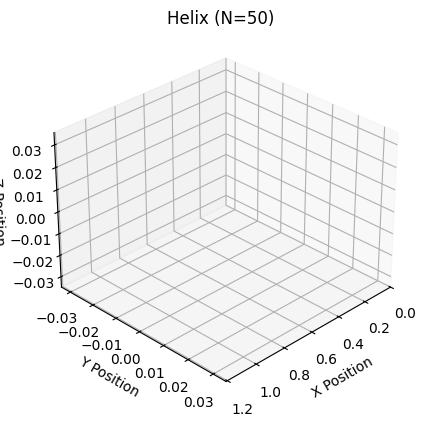

In [5]:
ani = dismech.get_animation(robot, t_arr, qs, options)
ani.save('slinky_pulling.gif')

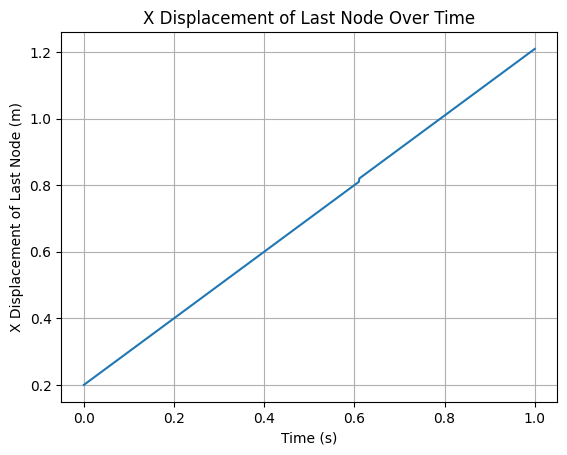

In [6]:
# plot the x discplacement of the last node over time
import matplotlib.pyplot as plt
last_node_x_disp = qs[:, robot.end_node_dof_index-3] # x is the first dof of the last node
plt.plot(t_arr, last_node_x_disp)
plt.xlabel('Time (s)')
plt.ylabel('X Displacement of Last Node (m)')
plt.title('X Displacement of Last Node Over Time')
plt.grid()

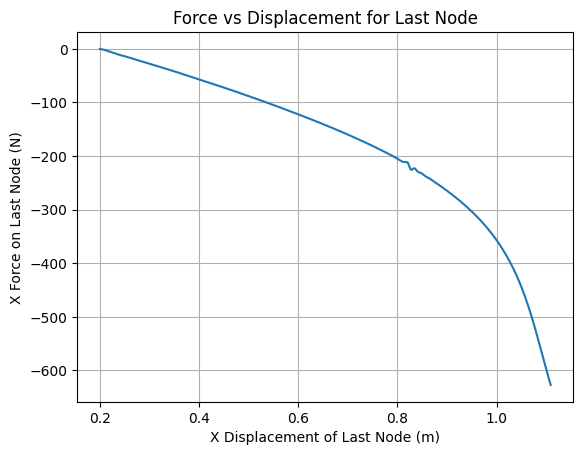

In [7]:
# plot force vs displacement for the last node
last_idx_of_interest = 100 # ignore the last 100 frames where the force goes to zero
plt.figure()
plt.plot(last_node_x_disp[:-last_idx_of_interest], Fs_arr[:-last_idx_of_interest, 0]) # x component of the force
plt.xlabel('X Displacement of Last Node (m)')
plt.ylabel('X Force on Last Node (N)')
plt.title('Force vs Displacement for Last Node')
plt.grid()
plt.show()

In [8]:

t_end_of_interest = t_arr[-last_idx_of_interest] # time corresponding to the last 200 frames
print(f"Time at end of interest: {t_end_of_interest:.2f} seconds)")

print("t_array shape:", t_arr.shape)
useful_t_arr = t_arr[:-last_idx_of_interest]
print("Useful t_arr shape:", useful_t_arr.shape)

Time at end of interest: 0.90 seconds)
t_array shape: (452,)
Useful t_arr shape: (352,)


In [9]:
import numpy as np

def resample_uniform_time(F, t_array, num_points=10):
    """
    Resample force F(t) onto equally spaced time points.

    Args:
        F:        shape (N,)
        t_array:  shape (N,) (non-uniform time)
        num_points: number of desired samples

    Returns:
        t_uniform: shape (num_points,)
        F_uniform: shape (num_points,)
    """
    # Ensure arrays
    F = np.asarray(F)
    t_array = np.asarray(t_array)

    # Create equally spaced time grid
    t_uniform = np.linspace(t_array.min(), t_array.max(), num_points)

    # Interpolate F onto uniform time grid
    F_uniform = np.interp(t_uniform, t_array, F)

    return t_uniform, F_uniform

Resampled time points: [0.         0.01836735 0.03673469 0.05510204 0.07346939 0.09183673
 0.11020408 0.12857143 0.14693878 0.16530612 0.18367347 0.20204082
 0.22040816 0.23877551 0.25714286 0.2755102  0.29387755 0.3122449
 0.33061224 0.34897959 0.36734694 0.38571429 0.40408163 0.42244898
 0.44081633 0.45918367 0.47755102 0.49591837 0.51428571 0.53265306
 0.55102041 0.56938776 0.5877551  0.60612245 0.6244898  0.64285714
 0.66122449 0.67959184 0.69795918 0.71632653 0.73469388 0.75306122
 0.77142857 0.78979592 0.80816327 0.82653061 0.84489796 0.86326531
 0.88163265 0.9       ]
Resampled force points: [   0.           -4.54141824  -10.28855265  -15.02467406  -20.12683383
  -25.21893695  -30.40843005  -35.72205205  -40.97860371  -46.36824352
  -51.94483622  -57.38149407  -63.01506359  -68.71262505  -74.34625436
  -80.10355063  -86.1194517   -92.0682525   -98.13960131 -104.33232171
 -110.62810263 -117.02774564 -123.53648748 -130.16434075 -136.92614752
 -143.84479606 -150.94304717 -158.23943

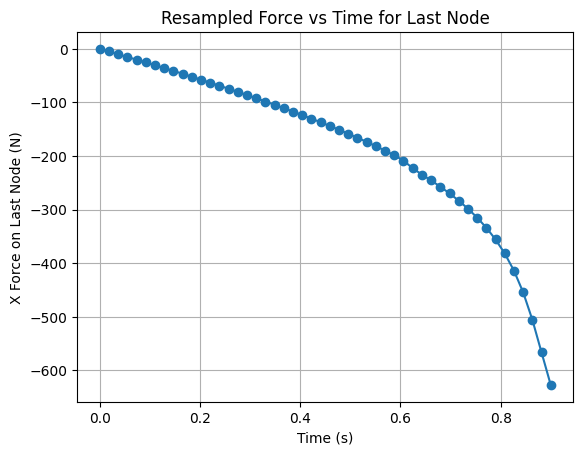

In [10]:
# data to train 
num_points = 50

t_to_train, F_to_train = resample_uniform_time(Fs_arr[:-last_idx_of_interest, 0], useful_t_arr, num_points=num_points)
print("Resampled time points:", t_to_train)
print("Resampled force points:", F_to_train)

plt.plot(t_to_train, F_to_train, 'o-')
plt.xlabel('Time (s)')
plt.ylabel('X Force on Last Node (N)')
plt.title('Resampled Force vs Time for Last Node')
plt.grid()

In [11]:
# initial location of last node x and the final location of the last node x
initial_last_node_x = qs[0, robot.end_node_dof_index-3]
final_last_node_x = qs[-last_idx_of_interest, robot.end_node_dof_index-3]

print(f"Initial last node x: {initial_last_node_x:.4f} m")
print(f"Final last node x: {final_last_node_x:.4f} m")

# save in .npz format
np.savez('slinky_pulling_force_data.npz', F=F_to_train, initial_last_node_x=initial_last_node_x, final_last_node_x=final_last_node_x)

Initial last node x: 0.2000 m
Final last node x: 1.1100 m
